**Assignment 2**


**Question 1**


First, we import the required packages and load the dataset.

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from torch.utils.data import Dataset, DataLoader

# Set to True if using ml.p2.xlarge Instances
FLAG_GPU = False


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=0.5, std=1.0)])
dataset = datasets.MNIST(root='../data', download=True, transform=transform)



We then reshape the data into a matrix $X \in \mathbb{R}^{60000 \times 784}$ and centre each feature column.

In [2]:
X = dataset.data.float().reshape(len(dataset), -1)
column_means = X.mean(dim=0, keepdim=True)
X -= column_means
print(X.shape)

torch.Size([60000, 784])


We can now compute the SVD of the centred data matrix $X$.


In [3]:
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
print("Shape of U, S and Vh:\n", U.shape, S.shape, Vh.shape)

Shape of U, S and Vh:
 torch.Size([60000, 784]) torch.Size([784]) torch.Size([784, 784])


After computing the SVD of $X$, we can extract the first two principal directions from the matrix $V$.


In [4]:
# First two principal directions
V_2 = Vh[:2, :].T           # shape: [784, 2]

# PCA coordinates for every image
X_pca = X @ V_2             # shape: [60000, 2]

print(X_pca.shape)

torch.Size([60000, 2])


We can then plot the projection onto the first two principal components as follows.


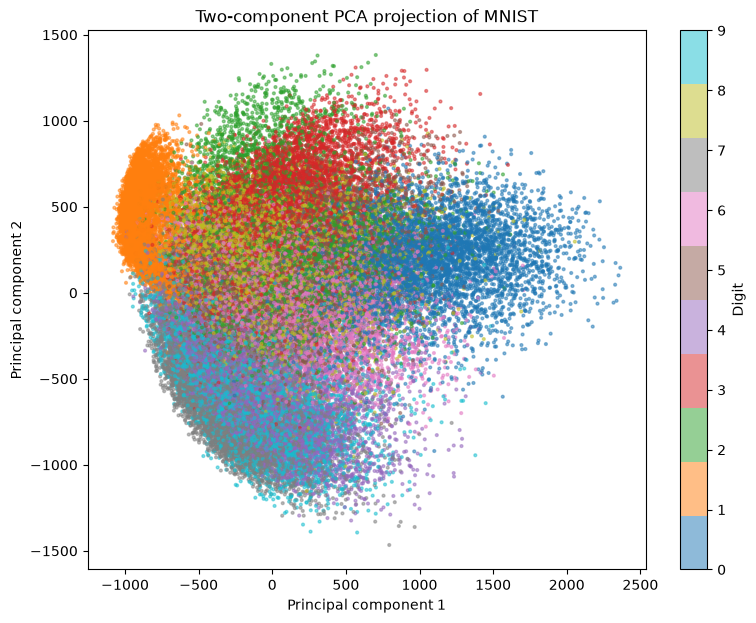

In [5]:
labels = dataset.targets

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0].cpu(),
    X_pca[:, 1].cpu(),
    c=labels.cpu(),
    cmap="tab10",
    s=4,
    alpha=0.5
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-component PCA projection of MNIST")
plt.show()

In this plot of the first two principal components of the dataset, there is a large amount of data and some overlap between classes, but each digit remains somewhat clustered with other examples of the same digit.


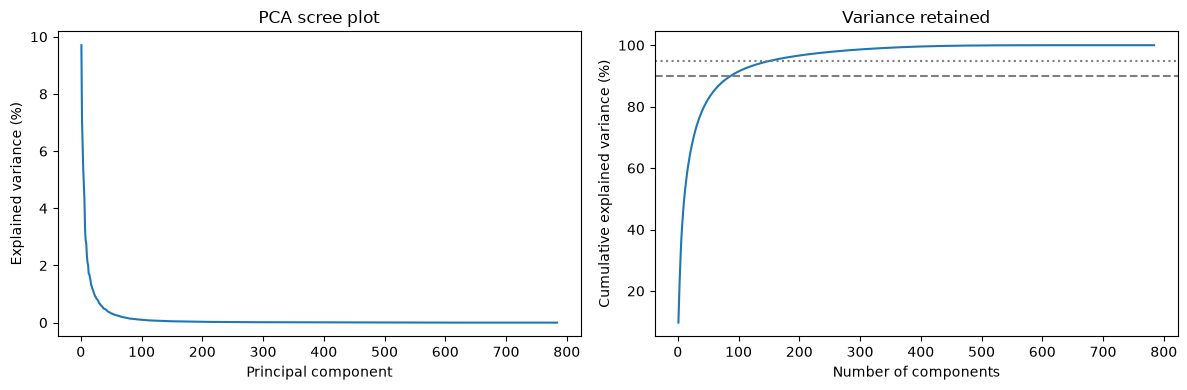

2 components retain 16.80%
10 components retain 48.82%
50 components retain 82.46%
100 components retain 91.46%
Components needed for 90% variance: 87
Components needed for 95% variance: 154


In [6]:
explained_ratio = S.square() / S.square().sum()
cumulative = explained_ratio.cumsum(dim=0)
components = np.arange(1, len(S) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(components, 100 * explained_ratio.cpu().numpy())
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("PCA scree plot")

axes[1].plot(components, 100 * cumulative.cpu().numpy())
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance (%)")
axes[1].set_title("Variance retained")
axes[1].axhline(90, color="grey", linestyle="--")
axes[1].axhline(95, color="grey", linestyle=":")

plt.tight_layout()
plt.show()

for k in [2, 10, 50, 100]:
    print(f"{k} components retain {100 * cumulative[k-1].item():.2f}%")

for target in [0.90, 0.95]:
    k = int((cumulative < target).sum().item()) + 1
    print(f"Components needed for {target:.0%} variance: {k}")

**Is there an "elbow"; or equivalently, do a small number of singular values explain most of the variance in the data? With reference to the previous answer, we can assess whether PCA could be used to form a low-dimensional representation of the dataset.**


The scree plot shows an initial steep decrease in the singular values, followed by a gradual flattening. There is an elbow, although it is fairly broad, and there is no single point at which the curve becomes completely flat. This suggests that the first few components capture a proportion of the overall varaince but we do need a lot more than the 2 used for generating this plot as around 83% of the varaince is not represented. 

In our output we see that we need 87 components of account for 90% of the variance so I would say we would need at least 50 odd components to have a good represenation of the dataset. 


**Question 2**

Research a second dimension reduction technique (there are possibilities listed in the text) and implement it to generate a similar (in nature) two-dimensional scatter plot to the one shown above.

The second dimension reduction technique I chose to implement is a variational autoencoder (VAE), because it is a standard deep-learning approach and is well suited to learning a compact latent representation of the data.


Epoch 1: loss = 189.8609
Epoch 2: loss = 166.9480
Epoch 3: loss = 162.9919
Epoch 4: loss = 160.5655
Epoch 5: loss = 158.8994


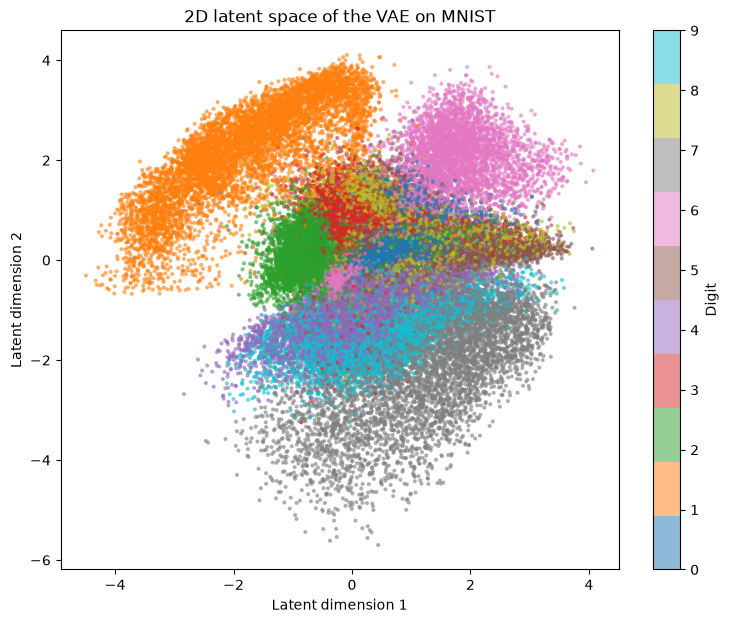

In [7]:
X_vae = dataset.data.float().reshape(len(dataset), -1) / 255.0

latent_dim = 2

class VAE(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(784, 400),
            torch.nn.ReLU()
        )
        self.mu_head = torch.nn.Linear(400, latent_dim)
        self.logvar_head = torch.nn.Linear(400, latent_dim)

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 400),
            torch.nn.ReLU(),
            torch.nn.Linear(400, 784),
            torch.nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


def loss_function(recon_x, x, mu, logvar):
    bce = torch.nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld


model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

loader = torch.utils.data.DataLoader(
    X_vae,
    batch_size=128,
    shuffle=True
)

for epoch in range(1, 6):
    model.train()
    total_loss = 0.0

    for batch_x in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(batch_x)
        loss = loss_function(recon, batch_x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}: loss = {total_loss / len(X_vae):.4f}")

with torch.no_grad():
    mu, _ = model.encode(X_vae)
    z = mu.numpy()

labels = dataset.targets.numpy()

plt.figure(figsize=(9, 7))
plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", s=4, alpha=0.5)
plt.colorbar(label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D latent space of the VAE on MNIST")
plt.show()

**Question 3**

For this question I will prove that ReLU is a convex function. ReLU is defined as:

$$
f(x_i)=\max(0,x_i)
$$
and to establish convexity we must show that:
$$
\lambda f(x_1)+(1-\lambda)f(x_2) \geq f(\lambda x_1 + (1-\lambda)x_2) \text{ where } 0 \leq \lambda \leq 1 \\
$$
When we substitute in ReLU: 
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \max(0, \lambda x_1 + (1-\lambda)x_2)
$$
Since $\max(0,x_i) \geq x_i$ and both $\lambda,\  1 - \lambda \geq 0$,
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \lambda x_1 + (1-\lambda)x_2
$$
With the both terms on the left hand side being nonnegative, the left-hand is therefore at least maximum of these two lower bounds.
$$
\lambda \max(0,x_1)+(1-\lambda)\max(0,x_2) \geq \max(0, \lambda x_1 + (1-\lambda)x_2)
$$
This establishes the convexity inequality $\forall \  x_1,x_2 \in \mathbb{R}$ and $\lambda \in [0,1]$. Hence ReLU is a convex function.

We have proved that ReLU is convex despite being nondifferentiable at 0, as spoken about in forum 5 neural networks are a nonconvex optimisation problem and ReLU being convex does not convert it to being a convex optimisation. Other activation functions such as sigmoid and tanh are not globally convex. 

**Question 4**

shape of images torch.Size([32, 1, 28, 28])


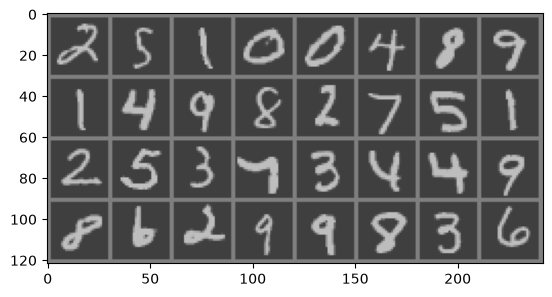

Labels were:
[[2 5 1 0 0 4 8 9]
 [1 4 9 8 2 7 5 1]
 [2 5 3 7 3 4 4 9]
 [8 6 2 9 9 8 3 6]]


In [8]:
class MLPNet(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = [nn.Flatten()]
        input_size = 784

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))
        layers.append(nn.LogSoftmax(dim=1))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

# Training and test datasets
trainset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

testset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)



def imshow(img, l):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    print('Labels were:')
    print(l.reshape(-1, 8).numpy())


# Load a sample batch of training data
images, labels = next(iter(trainloader))
print('shape of images', images.shape)

# Display the batch
imshow(utils.make_grid(images), labels)


In [9]:
shallow = MLPNet([288])
deep = MLPNet([192, 192, 192])

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Shallow:", count_parameters(shallow))
print("Deep:", count_parameters(deep))

Shallow: 228970
Deep: 226762


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep evaluation batching fixed throughout the experiments.
testloader = DataLoader(
    testset, batch_size=1024, shuffle=False, num_workers=0
)

def run_experiment(hidden_sizes, batch_size, seed):
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    # Separate generator makes data ordering independent of model size.
    generator = torch.Generator().manual_seed(seed)

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0
    )

    net = MLPNet(hidden_sizes).to(device)
    criterion = nn.NLLLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)

    history = []
    total_training_time = 0.0

    for epoch in range(5):
        net.train()
        total_loss = 0.0

        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()

        for inputs, labels in trainloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Weight by batch size because the final batch may be smaller.
            total_loss += loss.item() * labels.size(0)

        if device.type == "cuda":
            torch.cuda.synchronize()
        total_training_time += time.perf_counter() - start

        net.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                predictions = net(inputs).argmax(dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)

        history.append({
            "epoch": epoch + 1,
            "train_loss": total_loss / len(trainset),
            "test_accuracy": 100 * correct / total
        })

    return {
        "seed": seed,
        "batch_size": batch_size,
        "parameters": count_parameters(net),
        "accuracy": history[-1]["test_accuracy"],
        "training_seconds": total_training_time,
        "history": history
    }

In [11]:
architectures = {
    "Shallow": [288],
    "Deep": [192, 192, 192]
}

seeds = range(5)
architecture_results = []

for name, hidden_sizes in architectures.items():
    for seed in seeds:
        result = run_experiment(hidden_sizes, batch_size=64, seed=seed)
        result["architecture"] = name
        architecture_results.append(result)

        print(name, seed, round(result["accuracy"], 2))

Shallow 0 97.23
Shallow 1 97.26
Shallow 2 97.03
Shallow 3 96.52
Shallow 4 96.81
Deep 0 97.27
Deep 1 96.48
Deep 2 96.32
Deep 3 96.94
Deep 4 96.68


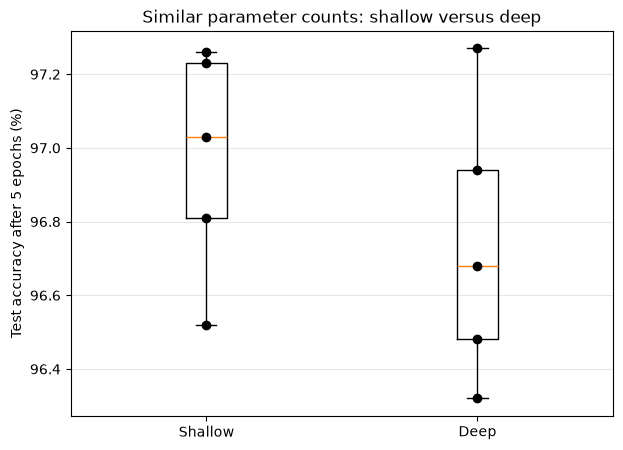

In [12]:
names = list(architectures)
scores = [
    [r["accuracy"] for r in architecture_results
     if r["architecture"] == name]
    for name in names
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(scores)

for position, values in enumerate(scores, start=1):
    ax.scatter([position] * len(values), values, color="black", zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(names)
ax.set_ylabel("Test accuracy after 5 epochs (%)")
ax.set_title("Similar parameter counts: shallow versus deep")
ax.grid(axis="y", alpha=0.3)
plt.show()

In [13]:
batch_sizes = [8, 32, 128, 512, 2048, 4096]
batch_results = []

for batch_size in batch_sizes:
    for seed in seeds:
        result = run_experiment([288], batch_size, seed)
        batch_results.append(result)

        print(batch_size, seed, round(result["accuracy"], 2))

8 0 96.64
8 1 96.94
8 2 96.23
8 3 96.77
8 4 95.83
32 0 97.29
32 1 97.22
32 2 96.78
32 3 96.62
32 4 96.79
128 0 97.19
128 1 97.09
128 2 96.8
128 3 96.89
128 4 96.91
512 0 95.0
512 1 95.02
512 2 94.53
512 3 95.3
512 4 94.65
2048 0 91.67
2048 1 91.72
2048 2 92.12
2048 3 91.89
2048 4 91.94
4096 0 90.58
4096 1 90.31
4096 2 90.74
4096 3 90.64
4096 4 90.75


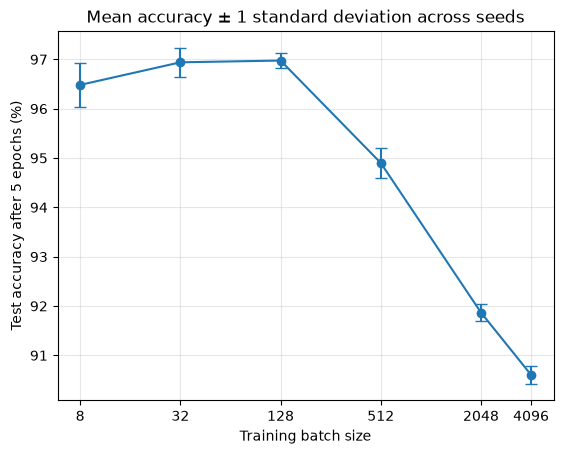

In [14]:
means = [
    np.mean([r["accuracy"] for r in batch_results
             if r["batch_size"] == b])
    for b in batch_sizes
]

stds = [
    np.std([r["accuracy"] for r in batch_results
            if r["batch_size"] == b], ddof=1)
    for b in batch_sizes
]

fig, ax = plt.subplots()
ax.errorbar(batch_sizes, means, yerr=stds, fmt="o-", capsize=4)
ax.set_xscale("log", base=2)
ax.set_xticks(batch_sizes)
ax.set_xticklabels(batch_sizes)
ax.set_xlabel("Training batch size")
ax.set_ylabel("Test accuracy after 5 epochs (%)")
ax.set_title("Mean accuracy ± 1 standard deviation across seeds")
ax.grid(alpha=0.3)
plt.show()

**Discussion of Results of Part 4)**

The above code runs a multiple experiments on various settings of a Neural Network trained of the MNIST dataset, each experiment used a setup of ReLU, negative log-likelihood loss, ADAM with a learning rate of 0.001 and five epochs. Each condition was repeated 5 times with a random seed and a fresh model. For the first experiment comparing a wide-but-shallow model with a deep-but-thin we held the batch size at 64 and approximately matched parameter counts. Parameter counts were approximately equal  to account for model size when comparing depth and width.
Below in Table 1 is the setup and the results. 

**Table 1. Architecture and MNIST test accuracy of shallow and deep networks across five runs after five training epochs (batch size 64).**
| Architecture | Hidden layer widths | Parameters | Mean test accuracy | Sample standard deviation |
| ------------ | ------------------- | ---------: | -----------------: | ------------------------: |
| Shallow      | 288                 |    228,970 |            96.970% |   0.310 percentage points |
| Deep         | 192 → 192 → 192     |    226,762 |            96.738% |   0.377 percentage points |

Based on the results we can see that the shallow network performs 0.232 percentage points higher mean test accuracy than the deeper network and its sample standard deviation was also slightly lower. The results largely overlap, with the deep NN having the best overall single run accuracy at 97.27%. With only five runs we can say that these results show a modest advantage of the shallow-but-wide network than the deep-but-thin in this setup, however, we can not define any strong conclusions from this experiment overall. 

Here are the equations for the two different setups.

Shallow-but-wide $784 \to 288 \to 10$:

$$
h_1 = \operatorname{ReLU}(W_1x+b_1),
\qquad
\log(p) = \operatorname{LogSoftmax}(W_2h_1+b_2),
$$

where $ x \in \mathbb{R}^{784}, \ W_1 \in \mathbb{R}^{288 \times 784}, \ W_2 \in \mathbb{R}^{10 \times 288}, \ b_1 \in \mathbb{R}^{288}, \ b_2 \in \mathbb{R}^{10}. $

Deep-but-thin $784 \to 192 \to 192 \to 192 \to 10$:

$$
\begin{aligned}
h_1 &= \operatorname{ReLU}(W_1x+b_1),\\
h_2 &= \operatorname{ReLU}(W_2h_1+b_2),\\
h_3 &= \operatorname{ReLU}(W_3h_2+b_3),\\
\log(p) &= \operatorname{LogSoftmax}(W_4h_3+b_4).
\end{aligned}
$$

where $ x \in \mathbb{R}^{784}, \ W_1 \in \mathbb{R}^{192 \times 784}, \ W_2, W_3 \in \mathbb{R}^{192 \times 192}, \ W_4 \in \mathbb{R}^{10 \times 192} \ \& \ b_1, b_2, b_3 \in \mathbb{R}^{192}, \ b_4 \in \mathbb{R}^{10}. $

The shallow network only applies one hidden nonlinear transformation while the deeper network applies three. This additional depth allows for sucsessive transformations of the learned features, this is viewed as allowing for it to understand more complex representations. However, as shown in our experiment it does not guarentee higher accuracy at all levels. These results suggest that the shallower network has enough capacity for the task at hand and the shallower network also may have benefitted from only having 5 epochs for training whilst the deper network may have required more due to its increased complexity. This experiment did not establish why the shallower network performed slightly better. 


The next experiment was testing various batch sizes on the effect on testing accuracy. We chose to run this with the shallow network whilst keeping the other settings unchanged. Below is Table 2 with the results of the experiment. 

**Table 2. MNIST test accuracy of the shallow network across five runs after five epochs, for different training batch sizes.**

| Batch size | Mean test accuracy | Sample SD (percentage points) |
| ---------: | -----------------: | ----------------------------: |
|          8 |            96.482% |                         0.449 |
|         32 |            96.940% |                         0.296 |
|        128 |            96.976% |                         0.159 |
|        512 |            94.900% |                         0.310 |
|       2048 |            91.868% |                         0.180 |
|       4096 |            90.604% |                         0.179 |

Across the 6 different chosen batch sizes, sizes 32 and 128 had the best mean test accuracy with 128 having peforming only slightly better on average. 128 also had the lowest sample standard deviation whilst the smallest tested batch size 8, had the highest of almost half a percentage point.  Accuracy decreased substantially when you increased the batch size to 512 and larger. Therefore, the results favour more moderate batch sizes under these training settings. 

Batch size affects the outcome because larger batches generally reduce gradient-estimation noise and the number of updates across an epoch is $ = \lceil \frac{60,000}{B} \rceil$ where $B$ is the batch size. This means that the larger batches also generally recieve fewer updates, this lower overall accuracy could be explained by less optimisation progress within the five epochs. Our experiment cannot confirm this causality however. 


With all this considered, when choosing arcitecture and batch sizes one must, consider accuracy, training time and avaliable memory and so this is not suggesting that any one batch size or architecture is perfect for this problem. 